# Aim 3
Tara Cornwell June 2024

Adapted from Darici and Kuo

### First, let's simulate unperturbed and perturbed step conditions.

Without pert, work cost = 0.10649684084184916
Min. work, work cost = 0.07649701626001
Min. change in time, work cost = 0.08978783346136456
Min. change in velocity, work cost = 0.08167963202295858
With pert not considered in opt, work cost = 0.10649684084184916


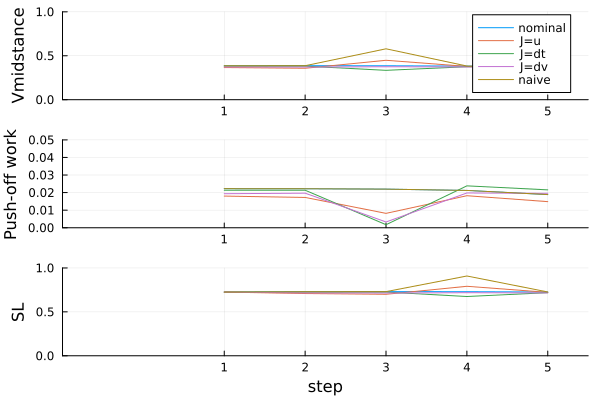

In [1]:
# Import necessary packages
using DynLoco_TC, Plots; 

# Clear variables
wstar_N = nothing

# Create structure for "walk"
wstar_N = findgait(WalkRW2lvs(α=0.27,safety=true), target=:speed=>0.42, varying=:P)

# Set number of steps: pre, pert, recovery
nsteps = 5

# Setup perturbation vector
perts = [1 1 1.5 1 1]

# Run optimization that minimizes push-off work
nominal_result = optwalk_TC(wstar_N, nsteps, boundarywork=false)
pert_result_u = optwalk_TC(wstar_N, nsteps, boundarywork=false, perts=perts)
pert_result_dt = optwalk_TC(wstar_N, nsteps, boundarywork=false, perts=perts, J="dt")
pert_result_dv = optwalk_TC(wstar_N, nsteps, boundarywork=false, perts=perts, J="dv")

# Apply naive control to perturbation condition
naive_result = multistep(wstar_N; Ps=nominal_result.steps.P, perts=perts)

# Print results
println("Without pert, work cost = ", nominal_result.workcost)
println("Min. work, work cost = ", pert_result_u.workcost)
println("Min. change in time, work cost = ", pert_result_dt.workcost)
println("Min. change in velocity, work cost = ", pert_result_dv.workcost)
println("With pert not considered in opt, work cost = ", naive_result.workcost)

# Plots
l = @layout [a; b; c]

p1 = plot(nominal_result.steps.vm, ylabel="Vmidstance", label="nominal")
plot!(pert_result_u.steps.vm, label="J=u")
plot!(pert_result_dt.steps.vm, label="J=dt")
plot!(pert_result_dv.steps.vm, label="J=dv")
plot!(naive_result.steps.vm, label="naive")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

p2 = plot(nominal_result.steps.Pwork, ylabel="Push-off work", label=false)
plot!(pert_result_u.steps.Pwork, label=false)
plot!(pert_result_dt.steps.Pwork, label=false)
plot!(pert_result_dv.steps.Pwork, label=false)
plot!(naive_result.steps.Pwork, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.05), xticks = 1:1:nsteps, yticks = 0:0.01:0.05)

p3 = plot(nominal_result.steps.steplength, xlabel="step", ylabel="SL", label=false)
plot!(pert_result_u.steps.steplength, label=false)
plot!(pert_result_dt.steps.steplength, label=false)
plot!(pert_result_dv.steps.steplength, label=false)
plot!(naive_result.steps.steplength, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

plot(p1, p2, p3, layout = l)

### Now let's try using the MPC controller.

With horizon = 1, PO work cost = 0.08431323308144031
With horizon = 2, PO work cost = 0.08235653543505927
With horizon = 3, PO work cost = 0.08658039521935658
With full horizon, PO work cost = 0.08885536888219323


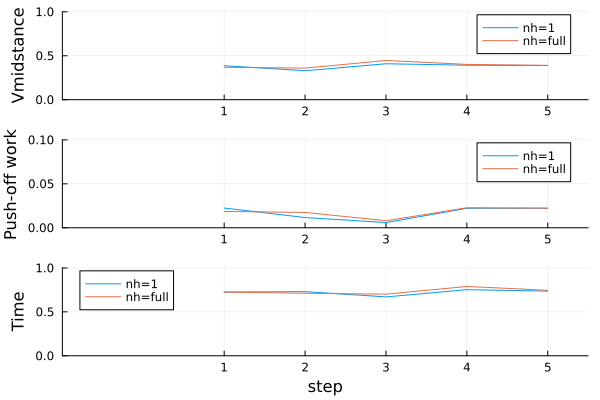

In [2]:
# Run optimization that minimizes push-off work
mpc_result1 = mpcstep(wstar_N, nsteps, 1, perts=perts)
mpc_result2 = mpcstep(wstar_N, nsteps, 2, perts=perts)
mpc_result3 = mpcstep(wstar_N, nsteps, 3, perts=perts)

nhorizon=nsteps
mpc_result_full = mpcstep(wstar_N, nsteps, nhorizon, perts=perts)

# Print results
println("With horizon = 1, PO work cost = ", mpc_result1.workcost)
println("With horizon = 2, PO work cost = ", mpc_result2.workcost)
println("With horizon = 3, PO work cost = ", mpc_result3.workcost)
println("With full horizon, PO work cost = ", mpc_result_full.workcost)

# Plots
l = @layout [a; b; c]

p1 = plot(mpc_result1.steps.vm, label="nh=1")
#plot!(mpc_result2.steps.vm, label="nh=2")
#plot!(mpc_result3.steps.vm, label="nh=3")
plot!(mpc_result_full.steps.vm, ylabel="Vmidstance", label="nh=full")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

p2 = plot(mpc_result1.steps.Pwork, ylabel="Push-off work", label="nh=1")
#plot!(mpc_result2.steps.Pwork, label="nh=2")
#plot!(mpc_result3.steps.Pwork, label="nh=3")
plot!(mpc_result_full.steps.Pwork, label="nh=full")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.1), xticks = 1:1:nsteps, yticks = 0:0.05:0.1)

p3 = plot(mpc_result1.steps.steplength, xlabel="step", ylabel="Time", label="nh=1")
#plot!(mpc_result2.steps.steplength, label="nh=2")
#plot!(mpc_result3.steps.steplength, label="nh=3")
plot!(mpc_result_full.steps.steplength, label="nh=full")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

plot(p1, p2, p3, layout = l)

### Test different objective functions

Min. work, work cost = 0.08885536888219323
Min. changes in step time, work cost = 0.08978783291463657
Min. changes in velocity, work cost = 0.08556843101757226


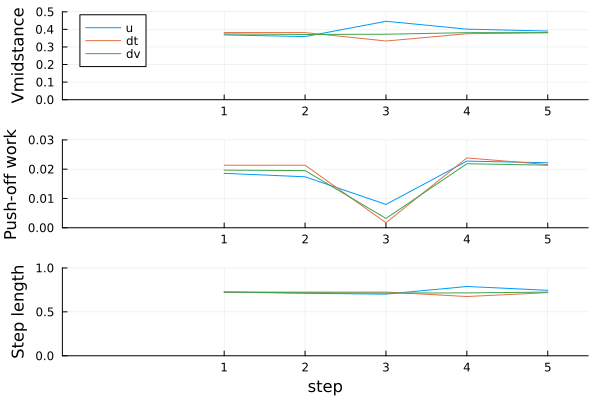

In [11]:
nhorizon=nsteps
min_P = zeros(nsteps)

#result_0 = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, weight=0)
#result_1 = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, weight=1)
#result_5 = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, weight=0.5)
#result_8 = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, weight=0.8)
#result_01 = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, weight=0.1)

result_u = Nothing
result_dt = Nothing
result_dv = Nothing

result_u = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, J="u", min_P=min_P)
result_dt = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, J="dt", min_P=min_P)
result_dv = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, J="dv", min_P=min_P)
#result_du = mpcstep(wstar_N, nsteps, nhorizon, perts=perts, J="du", min_P=minP)

# Print results
println("Min. work, work cost = ", result_u.workcost)
println("Min. changes in step time, work cost = ", result_dt.workcost)
println("Min. changes in velocity, work cost = ", result_dv.workcost)
#println("Min. changes in work, J = ", result_du.workcost)

# Plots
l = @layout [a; b; c]

p1 = plot(result_u.steps.vm, ylabel="Vmidstance", label="u")
plot!(result_dt.steps.vm, label="dt")
plot!(result_dv.steps.vm, label="dv")
#plot!(result_du.steps.vm, label="du")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.5), xticks = 1:1:nsteps, yticks = 0:0.1:0.5)

p2 = plot(result_u.steps.Pwork, ylabel="Push-off work", label=false)
plot!(result_dt.steps.Pwork, label=false)
plot!(result_dv.steps.Pwork, label=false)
#plot!(result_du.steps.Pwork, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.03), xticks = 1:1:nsteps, yticks = 0:0.01:0.03)

#p3 = plot(result_0.steps.tf, ylabel="Time", label="w=0")
#plot!(result_01.steps.tf, label="w=0.1")
#plot!(result_5.steps.tf, label="w=0.5")
#plot!(result_8.steps.tf, label="w=0.8")
#plot!(result_1.steps.tf, label="w=1")
#plot!(xlims = (-1, nsteps+0.5), xticks = 1:1:nsteps)
#plot!(xlims = (-1, nsteps+0.5), ylims = (0, 2.5), xticks = 1:1:nsteps, yticks = 0:0.5:2.5)

p4 = plot(result_u.steps.steplength, xlabel="step", ylabel="Step length", label=false)
plot!(result_dt.steps.steplength, label=false)
plot!(result_dv.steps.steplength, label=false)
#plot!(result_du.steps.steplength, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

plot(p1, p2, p4, layout = l)

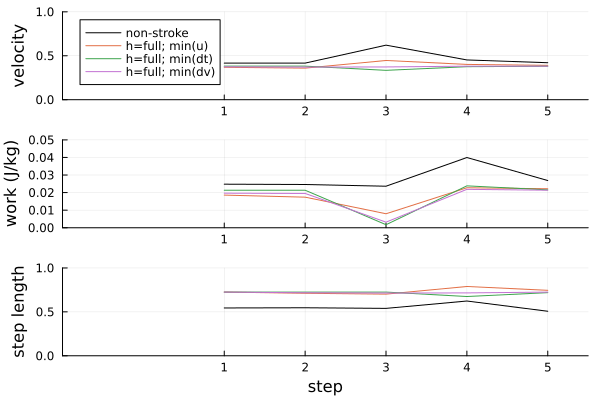

In [12]:
# Import experimental data
using CSV, DataFrames, Plots, Statistics

df_M_N = CSV.read("M_N.csv", header=["kg"], DataFrame) # mass
df_H_N = CSV.read("H_N.csv", header=["m"], DataFrame) # height
df_M_S = CSV.read("M_S.csv", header=["kg"], DataFrame) # mass
df_H_S = CSV.read("H_S.csv", header=["m"], DataFrame) # height

df_V_NW2 = CSV.read("V_N11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # velocities
df_U_NW2 = CSV.read("U_N11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # positive work
df_SL_NW2 = CSV.read("SL_N11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step lengths
df_ST_NW2 = CSV.read("ST_N11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step times

df_V_SW2 = CSV.read("V_S11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # velocities
df_U_SW2 = CSV.read("U_S11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # positive work
df_SL_SW2 = CSV.read("SL_S11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step lengths
df_ST_SW2 = CSV.read("ST_S11.csv", header=["P-3","P-2","P-1","P","R1","R2","R3"], DataFrame) # step times

# Plots
l = @layout [a; b; c]

g = 9.81
L = 1
M = 1
norm_v = (g^0.5)*(L^0.5)
norm_u = g*L # already mass-normalized

p1 = plot(mean(transpose(Matrix(df_V_NW2[:,2:6])),dims=2)/norm_v, linecolor =:black, ylabel="velocity", label="non-stroke",legend=:left)
#plot!(mean(transpose(Matrix(df_V_SW2[:,2:6])),dims=2)/norm_v, linecolor =:black, linestyle=:dash, label="stroke")
plot!(result_u.steps.vm, label="h=full; min(u)")
plot!(result_dt.steps.vm, label="h=full; min(dt)")
plot!(result_dv.steps.vm, label="h=full; min(dv)")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

p2 = plot(mean(transpose(Matrix(df_U_NW2[:,1:5])),dims=2)/norm_u, linecolor =:black, ylabel="work (J/kg)", label=false)
#plot!(mean(transpose(Matrix(df_U_SW2[:,1:5])),dims=2)/norm_u, linecolor =:black, linestyle=:dash, label=false)
plot!(result_u.steps.Pwork, label=false)
plot!(result_dt.steps.Pwork, label=false)
plot!(result_dv.steps.Pwork, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.05), xticks = 1:1:nsteps, yticks = 0:0.01:0.05)

p3 = plot(mean(transpose(Matrix(df_SL_NW2[:,2:6])),dims=2), linecolor =:black, xlabel="step", ylabel="step length", label=false)
#plot!(mean(transpose(Matrix(df_SL_SW2[:,2:6])),dims=2), linecolor =:black, linestyle=:dash, label=false)
plot!(result_u.steps.steplength, xlabel="step", label=false)
plot!(result_dt.steps.steplength, xlabel="step", label=false)
plot!(result_dv.steps.steplength, xlabel="step", label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

plot(p1, p2, p3, layout = l)

### For an unexpected perturbation, implement reactive balance (i.e., no change in control until after perturbation occurs)

Without compensation, work cost = 0.10670373592823398
With just reactive control, work cost = 0.12286591040029209
With full horizon MPC, work cost = 0.08885536888219323
With traj opt, work cost = 0.07649701626001


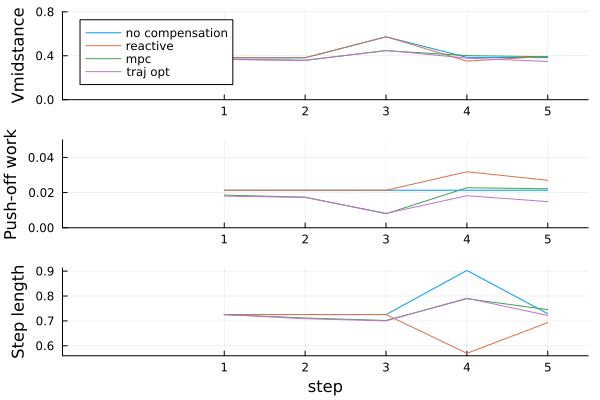

In [13]:
# No compensation, regardless of perturbation(s)
nocomp_result = multistep(wstar_N, Ps=fill(wstar_N.P,nsteps),perts = perts)

# No anticipatory control - just react after the perturbation happens
reactive_result1 = multistep(wstar_N, Ps=fill(wstar_N.P,3), perts = [1 1 1.5])
reactive_result2 = optwalk_TC(wstar_N, nsteps-3, boundaryvels=(reactive_result1.steps[end].vm,wstar_N.vm), perts =[1 1])

# Print results
println("Without compensation, work cost = ", nocomp_result.workcost)
println("With just reactive control, work cost = ", reactive_result1.workcost+reactive_result2.workcost)
println("With full horizon MPC, work cost = ", result_u.workcost)
println("With traj opt, work cost = ", pert_result_u.workcost)

# Plots
l = @layout [a; b; c]

p1 = plot(nocomp_result.steps.vm, ylabel="Vmidstance", label="no compensation",legend=:left)
plot!([reactive_result1.steps.vm; reactive_result2.steps.vm], label="reactive")
plot!(result_u.steps.vm, label="mpc")
plot!(pert_result_u.steps.vm, label="traj opt")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.8), xticks = 1:1:nsteps, yticks = 0:0.4:0.8)

p2 = plot(nocomp_result.steps.Pwork, ylabel="Push-off work", label=false)
plot!([reactive_result1.steps.Pwork; reactive_result2.steps.Pwork], label=false)
plot!(result_u.steps.Pwork, label=false)
plot!(pert_result_u.steps.Pwork, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.05), xticks = 1:1:nsteps, yticks = 0:0.02:0.05)

p3 = plot(nocomp_result.steps.steplength, xlabel="step", ylabel="Step length", label=false)
plot!([reactive_result1.steps.steplength; reactive_result2.steps.steplength], label=false)
plot!(result_u.steps.steplength, label=false)
plot!(pert_result_u.steps.steplength, label=false)
plot!(xlims = (-1, nsteps+0.5), xticks = 1:1:nsteps)

plot(p1, p2, p3, layout = l)

### Correlations between experimental and simulation results

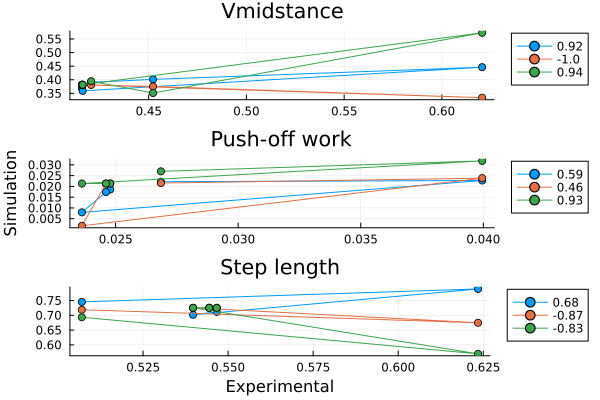

In [14]:
using Statistics, Plots, StatsPlots, GLM, StatsBase
l = @layout [a; b; c]

# VM
x = mean(transpose(Matrix(df_V_NW2[:,2:6])),dims=2)/norm_v

y = result_u.steps.vm
z=cor(x,y)[1]
#scatter(x,y)
#p1 = plot!()
p1 = plot(x,y,markershape=:circle,title="Vmidstance",label=round(z,digits=2),legend=:outertopright)

y = result_dt.steps.vm
z=cor(x,y)[1]
plot!(x,y,markershape=:circle,label=round(z,digits=2))

y = [reactive_result1.steps.vm; reactive_result2.steps.vm]
z=cor(x,y)[1]
plot!(x,y,markershape=:circle,label=round(z,digits=2))

# WORK
x = mean(transpose(Matrix(df_U_NW2[:,1:5])),dims=2)/norm_u

y = result_u.steps.Pwork
z=cor(x,y)[1]
p2 = plot(x,y,markershape=:circle,ylabel="Simulation",title="Push-off work",label=round(z,digits=2),legend=:outertopright)

y = result_dt.steps.Pwork
z=cor(x,y)[1]
plot!(x,y,markershape=:circle,label=round(z,digits=2))

y = [reactive_result1.steps.Pwork; reactive_result2.steps.Pwork]
z=cor(x,y)[1]
plot!(x,y,markershape=:circle,label=round(z,digits=2))

# SL
x = mean(transpose(Matrix(df_SL_NW2[:,2:6])),dims=2)

y = result_u.steps.steplength
z=cor(x,y)[1]
p3 = plot(x,y,markershape=:circle,xlabel="Experimental",title="Step length",label=round(z,digits=2),legend=:outertopright)

y = result_dt.steps.steplength
z=cor(x,y)[1]
plot!(x,y,markershape=:circle,label=round(z,digits=2))

y = [reactive_result1.steps.steplength; reactive_result2.steps.steplength]
z=cor(x,y)[1]
plot!(x,y,markershape=:circle,label=round(z,digits=2))

plot(p1, p2, p3, layout = l)

In [15]:
# Set up AIC to compare models

using Statistics, Plots, StatsPlots, GLM, StatsBase
xx = mean(transpose(Matrix(df_V_NW2[:,2:6])),dims=2)/norm_v
yy = Float64.(result_u.steps.vm)
yy = reshape(yy, length(yy), 1)

data = DataFrame(x=xx[1:5], y=yy[1:5])
mdl = lm(@formula(y ~ x), data)
println(round(aic(mdl); digits=3))


yy = Float64.(result_dt.steps.vm)
yy = reshape(yy, length(yy), 1)

data = DataFrame(x=xx[1:5], y=yy[1:5])
mdl = lm(@formula(y ~ x), data)
println(round(aic(mdl); digits=3))


yy = Float64.(result_dv.steps.vm)
yy = reshape(yy, length(yy), 1)

data = DataFrame(x=xx[1:5], y=yy[1:5])
mdl = lm(@formula(y ~ x), data)
println(round(aic(mdl); digits=3))

-24.345
-50.891
-34.245


### Start simulating stroke impairment
Testing bounding max on push-off work for one leg.

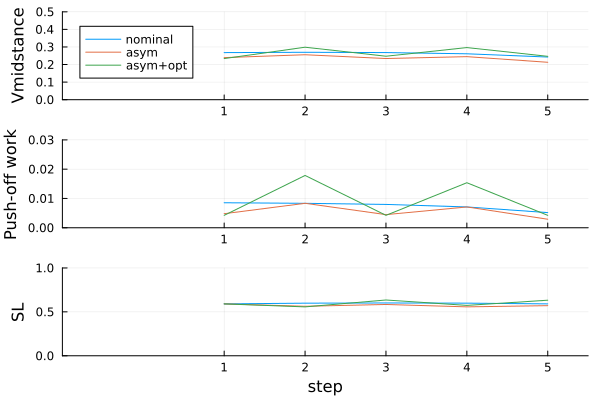

In [19]:
# Clear variables
wstar_S = nothing

# Create structure for "walk"
wstar_S = findgait(WalkRW2lvs(α=0.19,safety=true), target=:speed=>0.30, varying=:P)

# Not impaired
nominal_S = optwalk_TC(wstar_S, nsteps, boundarywork=false)

# Impaired but not optimal
percents = [0.75 1 0.75 1 0.75]
limit_Ps = nominal_S.steps.P.*percents'
impaired = multistep(wstar_S, Ps=limit_Ps)

# Impaired but optimal
impaired_opt = optwalk_TC(wstar_S, nsteps, boundarywork=false, max_P=[0.75 2 0.75 2 0.75])

# Plots
l = @layout [a; b; c]

p1 = plot(nominal_S.steps.vm, ylabel="Vmidstance", label="nominal", legend=:left)
plot!(impaired.steps.vm, label="asym")
plot!(impaired_opt.steps.vm, label="asym+opt")
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.5), xticks = 1:1:nsteps, yticks = 0:0.1:0.5)

p2 = plot(nominal_S.steps.Pwork, ylabel="Push-off work", label=false)
plot!(impaired.steps.Pwork, label=false)
plot!(impaired_opt.steps.Pwork, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 0.03), xticks = 1:1:nsteps, yticks = 0:0.01:0.03)

p3 = plot(nominal_S.steps.steplength, xlabel="step", ylabel="SL", label=false)
plot!(impaired.steps.steplength, label=false)
plot!(impaired_opt.steps.steplength, label=false)
plot!(xlims = (-1, nsteps+0.5), ylims = (0, 1), xticks = 1:1:nsteps, yticks = 0:0.5:1)

plot(p1, p2, p3, layout = l)